# PREV

In [1]:
import json

ROUTE_PATH = r"\\wsl.localhost\Ubuntu\home\bokosuka\Projects\AWSLastMile\model_build_inputs\route_data.json"
TIME_PATH = r"\\wsl.localhost\Ubuntu\home\bokosuka\Projects\AWSLastMile\model_build_inputs\travel_times.json"
PKG_PATH = r"\\wsl.localhost\Ubuntu\home\bokosuka\Projects\AWSLastMile\model_build_inputs\package_data.json"

In [2]:
with open(ROUTE_PATH) as f:
    route_data = json.load(f)

len(route_data)

6112

In [3]:
from pprint import pprint

first_route_id = list(route_data.keys())[0]
print("Route ID:", first_route_id)

pprint(route_data[first_route_id])

Route ID: RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77
{'date_YYYY_MM_DD': '2018-07-27',
 'departure_time_utc': '16:02:10',
 'executor_capacity_cm3': 3313071.0,
 'route_score': 'High',
 'station_code': 'DLA3',
 'stops': {'AD': {'lat': 34.099611,
                  'lng': -118.283062,
                  'type': 'Dropoff',
                  'zone_id': 'P-12.3C'},
           'AF': {'lat': 34.101587,
                  'lng': -118.291125,
                  'type': 'Dropoff',
                  'zone_id': 'A-1.2D'},
           'AG': {'lat': 34.089727,
                  'lng': -118.28553,
                  'type': 'Dropoff',
                  'zone_id': 'A-2.1A'},
           'BA': {'lat': 34.096132,
                  'lng': -118.292869,
                  'type': 'Dropoff',
                  'zone_id': 'A-1.2C'},
           'BE': {'lat': 34.098482,
                  'lng': -118.286243,
                  'type': 'Dropoff',
                  'zone_id': 'P-13.3B'},
           'BG': {'lat': 34.102251

In [4]:
route = route_data[first_route_id]

print(route.keys())              # top-level keys
print(len(route["stops"]))       # number of stops

first_stop = list(route["stops"].keys())[0]
print(route["stops"][first_stop])

dict_keys(['station_code', 'date_YYYY_MM_DD', 'departure_time_utc', 'executor_capacity_cm3', 'route_score', 'stops'])
119
{'lat': 34.099611, 'lng': -118.283062, 'type': 'Dropoff', 'zone_id': 'P-12.3C'}


In [5]:
import pandas as pd

rows = []
for stop_id, stop in route["stops"].items():
    rows.append({
        "stop_id": stop_id,
        "lat": stop["lat"],
        "lng": stop["lng"],
        "type": stop.get("type", None)
    })

df_stops = pd.DataFrame(rows)
df_stops.head()

,stop_id,lat,lng,type
0,AD,34.099611,-118.283062,Dropoff
1,AF,34.101587,-118.291125,Dropoff
2,AG,34.089727,-118.285530,Dropoff
3,BA,34.096132,-118.292869,Dropoff
4,BE,34.098482,-118.286243,Dropoff


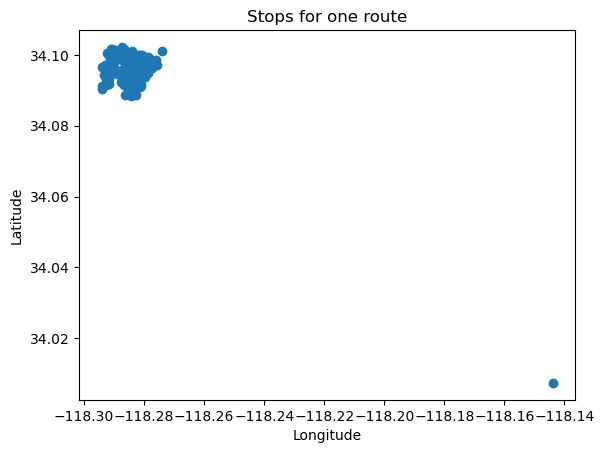

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df_stops["lng"], df_stops["lat"])
plt.title("Stops for one route")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [7]:
with open(TIME_PATH) as f:
    travel_data = json.load(f)

first_route = list(travel_data.keys())[0]
first_stop = list(travel_data[first_route].keys())[0]

print("Route:", first_route)
print("From stop:", first_stop)

list(travel_data[first_route][first_stop].items())[:5]

Route: RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77
From stop: AD


[('AD', 0.0), ('AF', 198.3), ('AG', 264.9), ('BA', 268.9), ('BE', 89.4)]

In [8]:
with open(PKG_PATH) as f:
    pkg_data = json.load(f)

first_route = list(pkg_data.keys())[0]
first_stop = list(pkg_data[first_route].keys())[0]

pkg_data[first_route][first_stop]

{'PackageID_9d7fdd03-f2cf-4c6f-9128-028258fc09ea': {'scan_status': 'DELIVERED',
  'time_window': {'start_time_utc': nan, 'end_time_utc': nan},
  'planned_service_time_seconds': 59.3,
  'dimensions': {'depth_cm': 25.4, 'height_cm': 7.6, 'width_cm': 17.8}},
 'PackageID_5541e679-b7bd-4992-b288-e862f6c84ae7': {'scan_status': 'DELIVERED',
  'time_window': {'start_time_utc': '2018-07-27 16:00:00',
   'end_time_utc': '2018-07-28 00:00:00'},
  'planned_service_time_seconds': 59.3,
  'dimensions': {'depth_cm': 25.4, 'height_cm': 12.7, 'width_cm': 17.8}},
 'PackageID_84d0295b-1adb-4a33-a65e-f7d6247c7a07': {'scan_status': 'DELIVERED',
  'time_window': {'start_time_utc': nan, 'end_time_utc': nan},
  'planned_service_time_seconds': 59.3,
  'dimensions': {'depth_cm': 39.4, 'height_cm': 7.6, 'width_cm': 31.8}}}

In [9]:
import json
print(json.dumps(route_data[first_route_id], indent=2)[:2000])

{
  "station_code": "DLA3",
  "date_YYYY_MM_DD": "2018-07-27",
  "departure_time_utc": "16:02:10",
  "executor_capacity_cm3": 3313071.0,
  "route_score": "High",
  "stops": {
    "AD": {
      "lat": 34.099611,
      "lng": -118.283062,
      "type": "Dropoff",
      "zone_id": "P-12.3C"
    },
    "AF": {
      "lat": 34.101587,
      "lng": -118.291125,
      "type": "Dropoff",
      "zone_id": "A-1.2D"
    },
    "AG": {
      "lat": 34.089727,
      "lng": -118.28553,
      "type": "Dropoff",
      "zone_id": "A-2.1A"
    },
    "BA": {
      "lat": 34.096132,
      "lng": -118.292869,
      "type": "Dropoff",
      "zone_id": "A-1.2C"
    },
    "BE": {
      "lat": 34.098482,
      "lng": -118.286243,
      "type": "Dropoff",
      "zone_id": "P-13.3B"
    },
    "BG": {
      "lat": 34.102251,
      "lng": -118.287403,
      "type": "Dropoff",
      "zone_id": "P-13.2A"
    },
    "BP": {
      "lat": 34.095585,
      "lng": -118.28179,
      "type": "Dropoff",
      "zone_id": 

---
---
# NEW

In [11]:
!pip install ijson

In [1]:
import os
from pathlib import Path

#DATA_DIR = Path(r"C:\Users\lalam\Downloads\sample_test")   # adjust to your path
DATA_DIR = Path(r"C:\Users\lalam\Downloads\model_build_inputs_remapped")   # adjust to your path

for fname in ["route_data.json", "actual_sequences.json", "travel_times.json", "package_data.json"]:
    size = os.path.getsize(DATA_DIR / fname)
    print(f"{fname}: {size / 1e6:.1f} MB")

route_data.json: 86.8 MB
actual_sequences.json: 17.8 MB
travel_times.json: 3065.0 MB
package_data.json: 382.2 MB


---
---

In [2]:
import json

def load_json(path):
    with open(path) as f:
        return json.load(f)

sequences = load_json(DATA_DIR / "actual_sequences.json")
sample_route = next(iter(sequences))
sample_actual = sequences[sample_route]["actual"]

print("Route:", sample_route)
print("First 5 items:", list(sample_actual.items())[:5])

Route: RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77
First 5 items: [('STOP_000001', 105), ('STOP_000002', 47), ('STOP_000003', 4), ('STOP_000004', 33), ('STOP_000005', 109)]


In [3]:
with open(DATA_DIR / "travel_times.json") as f:
    first_chunk = f.read(500)
print(first_chunk)

{"RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77": {"STOP_000001": {"STOP_000001": 0.0, "STOP_000002": 198.3, "STOP_000003": 264.9, "STOP_000004": 268.9, "STOP_000005": 89.4, "STOP_000006": 140.0, "STOP_000007": 138.4, "STOP_000008": 192.6, "STOP_000009": 216.6, "STOP_000010": 71.5, "STOP_000011": 153.3, "STOP_000012": 298.9, "STOP_000013": 163.7, "STOP_000014": 219.6, "STOP_000015": 100.5, "STOP_000016": 276.5, "STOP_000017": 200.6, "STOP_000018": 410.0, "STOP_000019": 175.9, "STOP_000020": 217.6


In [4]:
with open(DATA_DIR / "travel_times.json", "rb") as f:
    f.seek(-200, 2)  # last 200 bytes
    tail = f.read().decode("utf-8", errors="ignore")
print(tail)

.7, "STOP_383692": 651.9, "STOP_338965": 512.5, "STOP_352363": 333.6, "STOP_713150": 517.7, "STOP_601676": 641.0, "STOP_579814": 23.8, "STOP_338881": 281.1, "STOP_321188": 528.2, "STOP_713151": 0.0}}}


In [5]:
import json
import ijson
import numpy as np
import networkx as nx
from pathlib import Path
import pickle

DATA_DIR = Path(r"C:\Users\lalam\Downloads\model_build_inputs_remapped")   # adjust to your path
K_NEAREST = 4

def load_json(path):
    with open(path) as f:
        return json.load(f)

def iter_travel_times(path):
    """
    Yield (route_id, matrix) one route at a time from travel_times.json.
    Never loads the full file into memory.
    """
    with open(path, "rb") as f:
        for route_id, matrix in ijson.kvitems(f, ""):
            yield route_id, matrix

def build_route_graphs(route_id, matrix, sequences, packages, k=K_NEAREST):
    stops = list(matrix.keys())
    n = len(stops)
    if n == 0:
        return None, None
    stop_idx = {s: i for i, s in enumerate(stops)}

    # numpy matrix for fast k-NN
    T = np.full((n, n), np.inf)
    for i, src in enumerate(stops):
        for dst, t in matrix[src].items():
            if dst in stop_idx:
                T[i][stop_idx[dst]] = float(t)

    # ── node features ────────────────────────────────────────────────────────
    pkg = packages.get(route_id, {})

    def get_node_attrs(stop):
        stop_pkg = pkg.get(stop, {})
        if not isinstance(stop_pkg, dict) or not stop_pkg:
            return {"historical_fail_rate": 0.0, "n_packages": 0}
        statuses = [v.get("scan_status", "") for v in stop_pkg.values()]
        n_fail = sum(1 for s in statuses if s in ("DELIVERY_ATTEMPTED", "REJECTED"))
        return {
            "historical_fail_rate": n_fail / len(statuses) if statuses else 0.0,
            "n_packages": len(statuses),
        }

    # ── dense graph ───────────────────────────────────────────────────────────
    dense_G = nx.DiGraph()
    dense_G.graph["route_id"] = route_id
    for stop in stops:
        dense_G.add_node(stop, **get_node_attrs(stop))
    for i, src in enumerate(stops):
        for j, dst in enumerate(stops):
            if i != j and T[i][j] < np.inf:
                dense_G.add_edge(src, dst,
                    travel_time=T[i][j],
                    failure_prob=0.0,
                    adjusted_cost=T[i][j],
                )

    # ── sparse graph ──────────────────────────────────────────────────────────
    sparse_G = nx.DiGraph()
    sparse_G.graph["route_id"] = route_id
    for stop in stops:
        sparse_G.add_node(stop, **get_node_attrs(stop))

    # actual sequence edges
    seq_data = sequences.get(route_id, {})
    actual = seq_data.get("actual", {})
    sequence = [stop for stop, order in sorted(actual.items(), key=lambda x: x[1])]
    for a, b in zip(sequence, sequence[1:]):
        if dense_G.has_edge(a, b):
            sparse_G.add_edge(a, b, **dense_G[a][b], on_actual_route=True)

    # k-NN edges
    for i, src in enumerate(stops):
        candidates = sorted(
            [(T[i][j], stops[j]) for j in range(n) if j != i and T[i][j] < np.inf]
        )
        added = 0
        for _, dst in candidates:
            if added >= k:
                break
            if not sparse_G.has_edge(src, dst):
                sparse_G.add_edge(src, dst, **dense_G[src][dst], on_actual_route=False)
                added += 1

    # importance scores
    for node in sparse_G.nodes():
        in_e  = list(sparse_G.in_edges(node, data=True))
        out_e = list(sparse_G.out_edges(node, data=True))
        total_tt = sum(d["travel_time"] for *_, d in in_e + out_e)
        degree   = len(in_e) + len(out_e)
        on_route = sum(1 for *_, d in in_e + out_e if d.get("on_actual_route"))
        importance = (total_tt / max(degree, 1)) * (on_route / max(degree, 1))
        sparse_G.nodes[node]["importance_score"] = round(importance, 2)

    return dense_G, sparse_G


def build_all_graphs(data_dir, k=K_NEAREST):
    print("Loading routes, sequences, packages...")
    routes    = load_json(data_dir / "route_data.json")
    sequences = load_json(data_dir / "actual_sequences.json")
    packages  = load_json(data_dir / "package_data.json")

    all_dense, all_sparse = {}, {}
    total = len(routes)

    print(f"Streaming travel_times.json for {total} routes...")
    for i, (route_id, matrix) in enumerate(iter_travel_times(data_dir / "travel_times.json")):
        if route_id not in routes:
            continue
        dense_G, sparse_G = build_route_graphs(route_id, matrix, sequences, packages, k=k)
        if dense_G is not None:
            all_dense[route_id]  = dense_G
            all_sparse[route_id] = sparse_G

        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{total} routes processed")

    print(f"Done. Built graphs for {len(all_dense)} routes.")
    return all_dense, all_sparse


def build_graphs_batch(data_dir, k=K_NEAREST, limit=None, offset=0, save_dir=None):
    print("Loading routes, sequences, packages...")
    routes    = load_json(data_dir / "route_data.json")
    sequences = load_json(data_dir / "actual_sequences.json")
    packages  = load_json(data_dir / "package_data.json")

    all_dense, all_sparse = {}, {}
    total = len(routes)

    print(f"Streaming travel_times.json for {total} routes (batch offset={offset}, limit={limit})...")
    for i, (route_id, matrix) in enumerate(iter_travel_times(data_dir / "travel_times.json")):
        # skip until offset
        if i < offset:
            continue
        # stop after limit
        if limit is not None and (i - offset) >= limit:
            break

        if route_id not in routes:
            continue
        dense_G, sparse_G = build_route_graphs(route_id, matrix, sequences, packages, k=k)
        if dense_G is not None:
            all_dense[route_id]  = dense_G
            all_sparse[route_id] = sparse_G

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{total} routes processed")

    print(f"Done. Built graphs for {len(all_dense)} routes.")

    # optional save
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
        # Save dense graphs
        with open(save_dir / f"dense_batch_{offset}_{offset+len(all_dense)}.pkl", "wb") as f:
            pickle.dump(all_dense, f)
    
        # Save sparse graphs
        with open(save_dir / f"sparse_batch_{offset}_{offset+len(all_sparse)}.pkl", "wb") as f:
            pickle.dump(all_sparse, f)
    
        print(f"Saved batch graphs to {save_dir}")

    return all_dense, all_sparse


def inspect_route(route_id, all_dense, all_sparse):
    d, s = all_dense[route_id], all_sparse[route_id]
    actual_e = [(u,v) for u,v,d in s.edges(data=True) if d.get("on_actual_route")]
    knn_e    = [(u,v) for u,v,d in s.edges(data=True) if not d.get("on_actual_route")]
    top3 = sorted(s.nodes(data=True), key=lambda x: x[1].get("importance_score",0), reverse=True)[:3]
    print(f"\nRoute: {route_id}")
    print(f"  Dense  — nodes: {d.number_of_nodes()}, edges: {d.number_of_edges()}")
    print(f"  Sparse — nodes: {s.number_of_nodes()}, edges: {s.number_of_edges()}")
    print(f"  Sparse — actual: {len(actual_e)}, k-NN: {len(knn_e)}")
    print(f"  Top-3 importance: {[(n, a['importance_score']) for n,a in top3]}")

In [ ]:
if __name__ == "__main__":
    all_dense, all_sparse = build_all_graphs(DATA_DIR, k=K_NEAREST)
    sample_id = next(iter(all_dense))
    inspect_route(sample_id, all_dense, all_sparse)

In [6]:
if __name__ == "__main__":
    # Example: process 1000 routes at a time
    batch_size = 500
    save_dir = Path(r"C:\Users\lalam\Downloads\graphs")

    for start in range(0, 500, batch_size):
        print(f"\n=== Processing batch {start}–{start+batch_size} ===")
        all_dense, all_sparse = build_graphs_batch(
            DATA_DIR,
            k=K_NEAREST,
            limit=batch_size,
            offset=start,
            save_dir=save_dir
        )
        # Inspect one route from this batch
        if all_dense:
            sample_id = next(iter(all_dense))
            inspect_route(sample_id, all_dense, all_sparse)



=== Processing batch 0–500 ===
Loading routes, sequences, packages...
Streaming travel_times.json for 6112 routes (batch offset=0, limit=500)...
  100/6112 routes processed
  200/6112 routes processed
  300/6112 routes processed
  400/6112 routes processed
  500/6112 routes processed
Done. Built graphs for 500 routes.
Saved batch graphs to C:\Users\lalam\Downloads\graphs

Route: RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77
  Dense  — nodes: 118, edges: 13806
  Sparse — nodes: 118, edges: 589
  Sparse — actual: 117, k-NN: 472
  Top-3 importance: [('STOP_000103', np.float64(307.15)), ('STOP_000058', np.float64(52.46)), ('STOP_000031', np.float64(46.97))]


In [7]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_route(route_id, all_dense, all_sparse):
    dense_G = all_dense[route_id]
    sparse_G = all_sparse[route_id]

    plt.figure(figsize=(14, 6))

    # Dense graph
    plt.subplot(1, 2, 1)
    pos = nx.spring_layout(dense_G, seed=42)
    nx.draw(
        dense_G, pos,
        with_labels=True, node_size=500,
        node_color="lightblue", arrows=True
    )
    plt.title(f"Dense Graph — {route_id}")

    # Sparse graph
    plt.subplot(1, 2, 2)
    pos = nx.spring_layout(sparse_G, seed=42)
    edge_colors = ["red" if d.get("on_actual_route") else "gray"
                   for _, _, d in sparse_G.edges(data=True)]
    nx.draw(
        sparse_G, pos,
        with_labels=True, node_size=500,
        node_color="lightgreen", arrows=True,
        edge_color=edge_colors
    )
    plt.title(f"Sparse Graph — {route_id}")

    plt.tight_layout()
    plt.show()

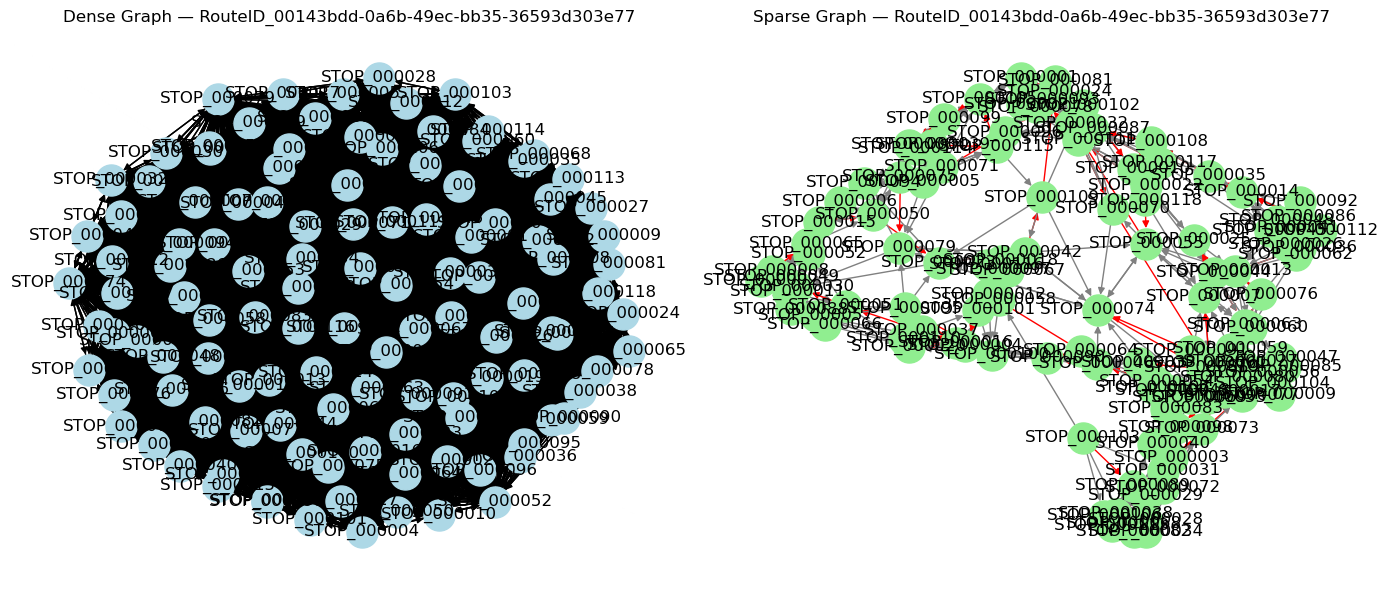

In [8]:
sample_id = next(iter(all_dense))   # pick one route ID
visualize_route(sample_id, all_dense, all_sparse)

---
---

In [7]:
import json
import numpy as np
import networkx as nx
from pathlib import Path

DATA_DIR = Path(r"C:\Users\lalam\Downloads\sample_test")   # adjust to your path
K_NEAREST = 4

# ── helpers ────────────────────────────────────────────────────────────────
def load_json(path):
    with open(path) as f:
        return json.load(f)

def iter_selected_travel_times(path, selected_routes):
    """
    Yield (route_id, matrix) only for selected routes.
    Loads the file once, then filters.
    """
    data = load_json(path)
    for route_id in selected_routes:
        if route_id in data:
            yield route_id, data[route_id]

# ── graph building ─────────────────────────────────────────────────────────
def build_route_graphs(route_id, matrix, sequences, packages, k=K_NEAREST):
    stops = list(matrix.keys())
    n = len(stops)
    if n == 0:
        return None, None
    stop_idx = {s: i for i, s in enumerate(stops)}

    # numpy matrix for fast k-NN
    T = np.full((n, n), np.inf)
    for i, src in enumerate(stops):
        for dst, t in matrix[src].items():
            if dst in stop_idx:
                T[i][stop_idx[dst]] = float(t)

    # node features
    pkg = packages.get(route_id, {})
    def get_node_attrs(stop):
        stop_pkg = pkg.get(stop, {})
        if not isinstance(stop_pkg, dict) or not stop_pkg:
            return {"historical_fail_rate": 0.0, "n_packages": 0}
        statuses = [v.get("scan_status", "") for v in stop_pkg.values()]
        n_fail = sum(1 for s in statuses if s in ("DELIVERY_ATTEMPTED", "REJECTED"))
        return {
            "historical_fail_rate": n_fail / len(statuses) if statuses else 0.0,
            "n_packages": len(statuses),
        }

    # dense graph
    dense_G = nx.DiGraph()
    dense_G.graph["route_id"] = route_id
    for stop in stops:
        dense_G.add_node(stop, **get_node_attrs(stop))
    for i, src in enumerate(stops):
        for j, dst in enumerate(stops):
            if i != j and T[i][j] < np.inf:
                dense_G.add_edge(src, dst,
                    travel_time=T[i][j],
                    failure_prob=0.0,
                    adjusted_cost=T[i][j],
                )

    # sparse graph
    sparse_G = nx.DiGraph()
    sparse_G.graph["route_id"] = route_id
    for stop in stops:
        sparse_G.add_node(stop, **get_node_attrs(stop))

    # actual sequence edges
    seq_data = sequences.get(route_id, {})
    actual = seq_data.get("actual", {})
    sequence = [stop for stop, order in sorted(actual.items(), key=lambda x: x[1])]
    for a, b in zip(sequence, sequence[1:]):
        if dense_G.has_edge(a, b):
            sparse_G.add_edge(a, b, **dense_G[a][b], on_actual_route=True)

    # k-NN edges
    for i, src in enumerate(stops):
        candidates = sorted(
            [(T[i][j], stops[j]) for j in range(n) if j != i and T[i][j] < np.inf]
        )
        added = 0
        for _, dst in candidates:
            if added >= k:
                break
            if not sparse_G.has_edge(src, dst):
                sparse_G.add_edge(src, dst, **dense_G[src][dst], on_actual_route=False)
                added += 1

    # importance scores
    for node in sparse_G.nodes():
        in_e  = list(sparse_G.in_edges(node, data=True))
        out_e = list(sparse_G.out_edges(node, data=True))
        total_tt = sum(d["travel_time"] for *_, d in in_e + out_e)
        degree   = len(in_e) + len(out_e)
        on_route = sum(1 for *_, d in in_e + out_e if d.get("on_actual_route"))
        importance = (total_tt / max(degree, 1)) * (on_route / max(degree, 1))
        sparse_G.nodes[node]["importance_score"] = round(importance, 2)

    return dense_G, sparse_G

# ── build graphs for selected routes ───────────────────────────────────────
def build_selected_graphs(data_dir, selected_routes, k=K_NEAREST):
    print("Loading sequences and packages...")
    sequences = load_json(data_dir / "actual_sequences.json")
    packages  = load_json(data_dir / "package_data.json")

    all_dense, all_sparse = {}, {}

    print(f"Building graphs for {len(selected_routes)} selected routes...")
    for route_id, matrix in iter_selected_travel_times(data_dir / "travel_times.json", selected_routes):
        dense_G, sparse_G = build_route_graphs(route_id, matrix, sequences, packages, k=k)
        if dense_G is not None:
            all_dense[route_id]  = dense_G
            all_sparse[route_id] = sparse_G

    print(f"Done. Built graphs for {len(all_dense)} routes.")
    return all_dense, all_sparse

# ── inspection ─────────────────────────────────────────────────────────────
def inspect_route(route_id, all_dense, all_sparse):
    d, s = all_dense[route_id], all_sparse[route_id]
    actual_e = [(u,v) for u,v,d in s.edges(data=True) if d.get("on_actual_route")]
    knn_e    = [(u,v) for u,v,d in s.edges(data=True) if not d.get("on_actual_route")]
    top3 = sorted(s.nodes(data=True), key=lambda x: x[1].get("importance_score",0), reverse=True)[:3]
    print(f"\nRoute: {route_id}")
    print(f"  Dense  — nodes: {d.number_of_nodes()}, edges: {d.number_of_edges()}")
    print(f"  Sparse — nodes: {s.number_of_nodes()}, edges: {s.number_of_edges()}")
    print(f"  Sparse — actual: {len(actual_e)}, k-NN: {len(knn_e)}")
    print(f"  Top-3 importance: {[(n, a['importance_score']) for n,a in top3]}")

In [7]:
# ── main ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Load route metadata
    routes = load_json(DATA_DIR / "route_data.json")

    # Option 1: pick explicit route IDs
    selected = [
        "RouteID_Test_002"   # replace with any route ID you want
    ]

    # Option 2: take the first N routes from route_data.json
    # selected = list(routes.keys())[:3]

    # Build graphs only for selected routes
    all_dense, all_sparse = build_selected_graphs(DATA_DIR, selected, k=K_NEAREST)

    # Inspect each selected route
    for rid in all_dense:
        inspect_route(rid, all_dense, all_sparse)


Loading sequences and packages...
Building graphs for 1 selected routes...
Done. Built graphs for 1 routes.

Route: RouteID_Test_002
  Dense  — nodes: 15, edges: 210
  Sparse — nodes: 15, edges: 74
  Sparse — actual: 14, k-NN: 60
  Top-3 importance: [('STOP_000014', np.float64(7.51)), ('STOP_000009', np.float64(7.26)), ('STOP_000010', np.float64(6.98))]


In [8]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_graphs(dense_G, sparse_G, route_id):
    plt.figure(figsize=(14, 6))

    # Dense graph
    plt.subplot(1, 2, 1)
    pos = nx.spring_layout(dense_G, seed=42)  # layout for consistency
    nx.draw(dense_G, pos, with_labels=True, node_size=500, node_color="lightblue", arrows=True)
    nx.draw_networkx_edge_labels(
        dense_G, pos,
        edge_labels={(u, v): f"{d['travel_time']:.1f}" for u, v, d in dense_G.edges(data=True)},
        font_size=8
    )
    plt.title(f"Dense Graph — {route_id}")

    # Sparse graph
    plt.subplot(1, 2, 2)
    pos = nx.spring_layout(sparse_G, seed=42)
    colors = ["red" if d.get("on_actual_route") else "gray" for _, _, d in sparse_G.edges(data=True)]
    nx.draw(sparse_G, pos, with_labels=True, node_size=500, node_color="lightgreen", arrows=True, edge_color=colors)
    nx.draw_networkx_edge_labels(
        sparse_G, pos,
        edge_labels={(u, v): f"{d['travel_time']:.1f}" for u, v, d in sparse_G.edges(data=True)},
        font_size=8
    )
    plt.title(f"Sparse Graph — {route_id}")

    plt.tight_layout()
    plt.show()

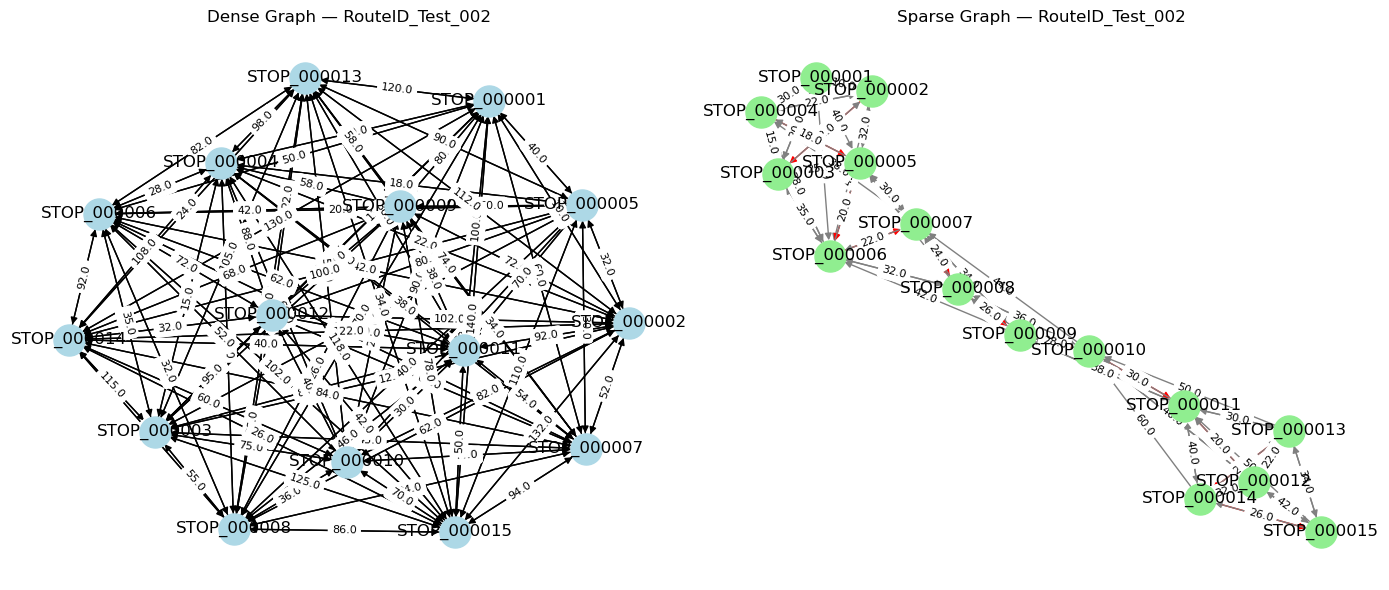

In [9]:
for rid in all_dense:
    visualize_graphs(all_dense[rid], all_sparse[rid], rid)